# **Machine Learning Project PART 2 | Step 1: Data Pre processing- ATU Winter 2024**  
**Author**: Lais Coletta Pereira  
**Lecturer**: Brian McGinley  

---

# Data Pre-processing

The first task will be to build a dataset from the annotated data. Here are the steps taken in this notebook:

1. **Extract Spectrogram for Each Call**:
   - For each annotated call, extract a spectrogram and store it as a raw 2D array (not as an image).
   - Use the frequency range specified in the annotations to ensure spectrograms are aligned in terms of time and frequency.
   - Save metadata with each spectrogram (e.g., annotation, category, frequency, time range).

2. **Pre-Processing for Longest and Broadest Spectrogram**:
   - Identify the longest call (by duration) and the broadest (by frequency) call.
   - Use these to set baseline spectrogram dimensions, ensuring consistency across all spectrograms.

3. **Saving Spectrograms as 2D Arrays**:
   - Processed spectrograms will be saved as `.npz` files (which can store both the spectrogram and metadata) in their respective directories.

4. **Create Spectrograms for "No-Call" Segments**:
   - Spectrograms must be created for time periods without annotated calls, as these represent "no-calls."
   - These "no-call" spectrograms should have the same frequency range as the call spectrograms, ensuring dataset consistency.

5. **Metadata Storage**:
   - For each spectrogram, associated metadata (e.g., annotation, call type, start and end times, frequency range) should be stored alongside it.

6. **Ensure Uniform Spectrogram Size**:
   - Spectrograms will be resized (padded or cropped) to match the baseline dimensions based on the longest time duration and broadest frequency range.

This process ensures that all spectrograms are uniform in size, and both calls and "no-calls" are processed and categorized correctly with their respective metadata.



In [1]:
#Imports
import os
import numpy as np
import pandas as pd
from scipy.io import wavfile
from scipy import signal
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
import os


In [2]:
# Define the output directory for spectrogram files and create it if it doesn't exist
output_dir = 'spectrogram_output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

***Function to load audio and annotations, reads .wav and .txt annotation files:***

In [3]:
def load_audio_and_annotation(file_base_name):
    """
    Loads the WAV audio and the associated annotation file.
    
    Parameters:
        - file_base_name (str): Base name of the audio and annotation file (without extension).
        
    Returns:
        - sample_rate (int): The sample rate of the audio file.
        - samples (np.array): The raw audio samples.
        - df (DataFrame): The annotation data.
    """
    # Load the WAV audio file
    audio_path = file_base_name + '.wav'
    sample_rate, samples = wavfile.read(audio_path)
    
    # Load the annotation file (assuming .txt format)
    annot_file_path = file_base_name + '.Table.1.selections.txt'
    df = pd.read_csv(annot_file_path, sep='\t')

    return sample_rate, samples, df


**Function to extract audio segments based on annotations**

Extract audio segments based on start and end times from annotations, storing each segment along with its relevant information in a list.

In [4]:
def extract_audio_segments(samples, sample_rate, annotations):
    """
    Extracts audio segments based on the annotations.
    
    Parameters:
        - samples (np.array): The raw audio data.
        - sample_rate (int): The sample rate of the audio.
        - annotations (DataFrame): The annotation file data.
        
    Returns:
        - segments (list of dict): List of audio segments with annotation information.
    """
    segments = []
    for _, row in annotations.iterrows():
        # Convert start and end time (in seconds) to sample indices
        start_time, end_time = row['Begin Time (s)'], row['End Time (s)']
        start_sample, end_sample = int(start_time * sample_rate), int(end_time * sample_rate)
        
        # Check if the start and end indices are valid within the audio length
        if start_sample >= end_sample or start_sample < 0 or end_sample > len(samples):
            print(f"Invalid segment: {start_time}-{end_time}s")
            continue
        
        segment = samples[start_sample:end_sample]
        segments.append({
            'Selection': row['Selection'],
            'Annotation': row['Annotation'],
            'Begin Time (s)': start_time,
            'End Time (s)': end_time,
            'audio_segment': segment,
            'Low Freq (Hz)': row['Low Freq (Hz)'],
            'High Freq (Hz)': row['High Freq (Hz)']
        })
    return segments

**Define a function to generate a spectrogram from the audio segment**

This function generates a spectrogram from an audio segment by applying the Short-Time Fourier Transform (STFT) using [scipy.signal.spectrogram](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html). 
It allows us to specify the frequency range (fmin, fmax) and other parameters like window length, FFT points, and overlap to control the resolution of the spectrogram. The function returns frequency bins, time bins, and the spectrogram data (2D array). I am using the spectrogram.ipynp as a source for this part.


In [5]:
def generate_spectrogram(audio_segment, sample_rate, fmin=20, fmax=1000, nperseg=1024, nfft=2048, noverlap=512):
    """
    Generates a spectrogram for a given audio segment.
    
    Parameters:
        - audio_segment (np.array): The raw audio data segment.
        - sample_rate (int): The sample rate of the audio.
        - fmin (int): The minimum frequency for the spectrogram (default 20 Hz).
        - fmax (int): The maximum frequency for the spectrogram (default 1000 Hz).
        - nperseg (int): The length of each segment for the FFT (default 1024).
        - nfft (int): The number of FFT points (default 2048).
        - noverlap (int): The number of points to overlap between segments (default 512).
        
    Returns:
        - frequencies (np.array): Frequency bins for the spectrogram.
        - times (np.array): Time bins for the spectrogram.
        - spectrogram_data (np.array): The 2D spectrogram data.
    """
    frequencies, times, spectrogram_data = signal.spectrogram(
        audio_segment, sample_rate, nperseg=nperseg, nfft=nfft, noverlap=noverlap, window='hann'
    )
    spectrogram_data = np.maximum(spectrogram_data, 1e-10)
    freq_slice = np.where((frequencies >= fmin) & (frequencies <= fmax))
    return frequencies[freq_slice], times, spectrogram_data[freq_slice]

***Calculate Baseline Parameters***
1. Iterate through folders: The function loops through each folder, list and reads the annotation files (those ending with `.Table.1.selections.txt`).

2. Read Annotations: For each annotation file, the function calculates the duration of each segment by subtracting the "Begin Time" from the "End Time". It also retrieves the minimum and maximum frequency ranges for each annotation.

3. Update Maximum Duration and Frequency Range: As each annotation file is processed, the function keeps track of:
   - The largest segment duration (`max_duration`).
   - The full frequency range (`max_freq_range`) encountered in the dataset.

After processing all the annotation files, the function assigns the values of `max_duration` and `max_freq_range` to the global variables `baseline_time` and `baseline_freq`. These values are used in further operations like padding or cropping spectrograms to ensure that all spectrograms have consistent dimensions.

In [6]:
def calculate_baselines(folder_paths):
    """
    Calculate the baseline segment duration and frequency range across all files in the folder paths.
    """
    global max_time, max_frequency
    
    max_time, max_frequency = 0, 0
    
    # Iterate through each folder in the folder_paths list
    for folder_path in folder_paths:
        # Loop through each file in the current folder
        for file in os.listdir(folder_path):
            if file.endswith('.wav'):
                file_base_name = os.path.splitext(file)[0]
                file_base_path = os.path.join(folder_path, file_base_name)
                
                # Load the audio and annotation
                sample_rate, samples, df = load_audio_and_annotation(file_base_path)
                
                # Extract segments for the current file
                segments = extract_audio_segments(samples, sample_rate, df)
                
                # Find the longest duration in terms of time
                for segment in segments:
                    max_time = max(max_time, segment['End Time (s)'] - segment['Begin Time (s)'])
                    max_frequency = max(max_frequency, segment['High Freq (Hz)'] - segment['Low Freq (Hz)'])


***Padding or Cropping Spectrograms***

This function ensures that a spectrogram has a consistent shape by either padding or cropping along both time and frequency axes. It calculates the desired dimensions based on a baseline time and frequency range, which are derived from the longest call in time and the broadest frequency range across all the segments. These values become the baseline for the largest spectrogram. The function then adjusts the spectrogram's time bins to match the maximum duration, and ensures the correct frequency bins are present by resizing according to the broadest frequency range. It uses NumPy operations like np.squeeze, np.pad, and np.reshape to adjust the spectrogram as needed.

In [7]:
def pad_or_crop_spectrogram(spectrogram_data, target_shape):
    """
    Pads or crops the spectrogram to match a target shape (frequency, time).
    
    Parameters:
        - spectrogram_data (np.array): The 2D spectrogram to be padded or cropped.
        - target_shape (tuple): The target shape (frequency, time).
        
    Returns:
        - padded_spectrogram (np.array): The padded or cropped spectrogram.
    """
    # Ensure spectrogram data is a numpy array
    spectrogram_data = np.array(spectrogram_data)

    # Check if the spectrogram is 2D (frequency x time)
    if spectrogram_data.ndim == 2:
        current_shape = spectrogram_data.shape
        padded_spectrogram = np.zeros(target_shape)

        # Check if the current spectrogram size is within bounds
        for i in range(min(current_shape[0], target_shape[0])):  # Frequencies
            for j in range(min(current_shape[1], target_shape[1])):  # Time steps
                padded_spectrogram[i, j] = float(spectrogram_data[i, j])
        return padded_spectrogram
    else:
        print(f"Error: Spectrogram data has invalid dimensions {spectrogram_data.shape}. Expected 2D.")
        raise ValueError(f"Spectrogram data must be 2D with dimensions (frequency, time), but got shape {spectrogram_data.shape}.")

***Create "No Call" Segments***

Identify the periods where no calls are made by analyzing the gaps between annotated call segments. It extracts the "no-call" portions from the audio samples and returns them as separate segments. The function handles any remaining no-call period after the last annotation and returns a list of the segmented intervals with no calls.

In [8]:
def create_no_call_segments(samples, sample_rate, call_annotations, silence_duration_threshold=0.5):
    """
    Creates 'no-call' segments from periods of silence based on gaps in the call annotations.
    
    Parameters:
        - samples (np.array): The raw audio data.
        - sample_rate (int): The sample rate of the audio.
        - call_annotations (DataFrame): The annotation data containing call start and end times.
        - silence_duration_threshold (float): Threshold duration in seconds to classify as 'no-call'.
        
    Returns:
        - no_call_segments (list of np.array): A list of no-call audio segments.
    """
    # Get the end times of existing calls
    call_end_times = call_annotations['End Time (s)'].values
    call_start_times = call_annotations['Begin Time (s)'].values
    
    # Sort calls by start times (just in case)
    sorted_start_times = np.sort(call_start_times)
    sorted_end_times = call_end_times[np.argsort(call_start_times)]
    
    # Generate the 'no-call' periods by looking at gaps between successive call end times and next start times
    no_call_segments = []
    for i in range(len(sorted_start_times) - 1):
        end_of_previous_call = sorted_end_times[i]
        start_of_next_call = sorted_start_times[i + 1]
        
        # If the gap between two calls is greater than the threshold, consider it as a 'no-call' segment
        if start_of_next_call - end_of_previous_call > silence_duration_threshold:
            start_sample = int(end_of_previous_call * sample_rate)
            end_sample = int(start_of_next_call * sample_rate)
            no_call_segment = samples[start_sample:end_sample]
            no_call_segments.append(no_call_segment)

    return no_call_segments

***Helper Function for Categorization***

Determines the category name based on the annotation name instead of the folder name.

In [9]:
def get_category_name(annotation):
    """
    Maps an annotation to a predefined category.
    
    Parameters:
        - annotation (str): The annotation label.
        
    Returns:
        - category (str): The category corresponding to the annotation.
    """
    category_mapping = {
        'Rupe A': 'rupe_A',
        'Rupe B': 'rupe_B',
        'Rupe C': 'rupe_C',
        'Growl B': 'growl_B',
        'Moan': 'moan',
        'G rupe': 'g_rupe',
        'Guttural rupe': 'g_rupe'
    }
    return category_mapping.get(annotation, 'unknown')

Load files, process audio, generate spectrograms, padding/cropping and saving the data:

In [10]:
# Folder paths for the WAV and annotation files
folder_paths = [
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Guttural rupe',
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B',
    r'C:\Users\Admin\Downloads\Samples Grey Seal\Moan'
]

dataset = []

# Calculate the baseline values for time and frequency
calculate_baselines(folder_paths)

# Now, max_time and max_frequency contain the baseline values
target_shape = (int(max_frequency), int(max_time))

# Process audio files and annotations
for folder_path in folder_paths:
    for file in os.listdir(folder_path):
        if file.endswith('.wav'):
            file_base_name = os.path.splitext(file)[0]
            file_base_path = os.path.join(folder_path, file_base_name)
            sample_rate, samples, df = load_audio_and_annotation(file_base_path)
            segments = extract_audio_segments(samples, sample_rate, df)

            # Categorize segments and add to the dataset
            for segment in segments:
                category = get_category_name(segment['Annotation'])
                segment['Category'] = category
                dataset.append(pd.DataFrame([segment]))

# Concatenate all segment data into a single DataFrame
final_df = pd.concat(dataset, ignore_index=True)

# Save spectrograms for all segments
for _, segment_info in final_df.iterrows():
    audio_segment = segment_info['audio_segment']
    frequencies, times, spectrogram_data = generate_spectrogram(
        audio_segment, sample_rate, fmin=segment_info['Low Freq (Hz)'], fmax=segment_info['High Freq (Hz)']
    )
    
    # Pad or crop the spectrogram to match the maximum size
    try:
        padded_spectrogram = pad_or_crop_spectrogram(spectrogram_data, target_shape)
    except ValueError as e:
        print(f"Error while processing {segment_info['Selection']} ({segment_info['Category']}): {e}")
        continue

    # Save spectrogram to an NPZ file
    npz_filename = f"{segment_info['Category']}_{segment_info['Begin Time (s)']}_{segment_info['End Time (s)']}.npz"
    npz_file_path = os.path.join(output_dir, npz_filename)
    np.savez(npz_file_path, spectrogram_data=padded_spectrogram, frequencies=frequencies, times=times)


### Spectrograms 

#### Guttural Rupe

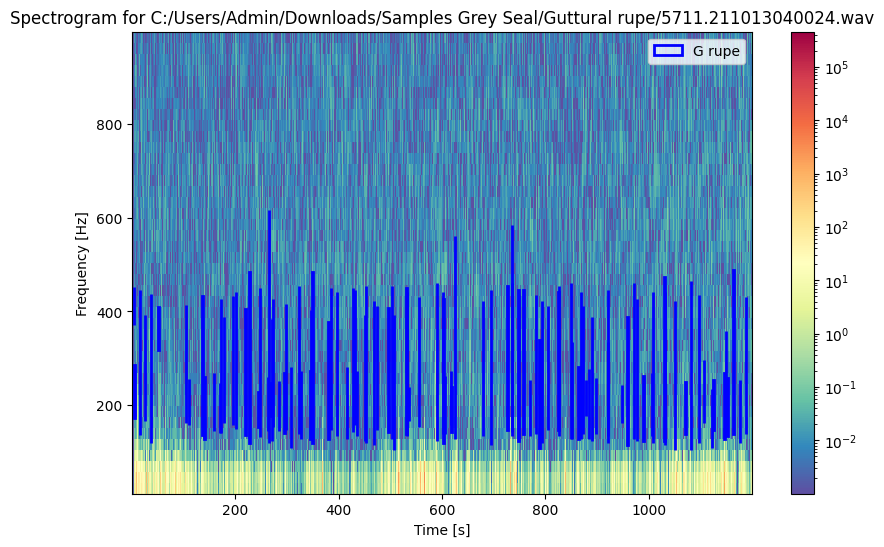

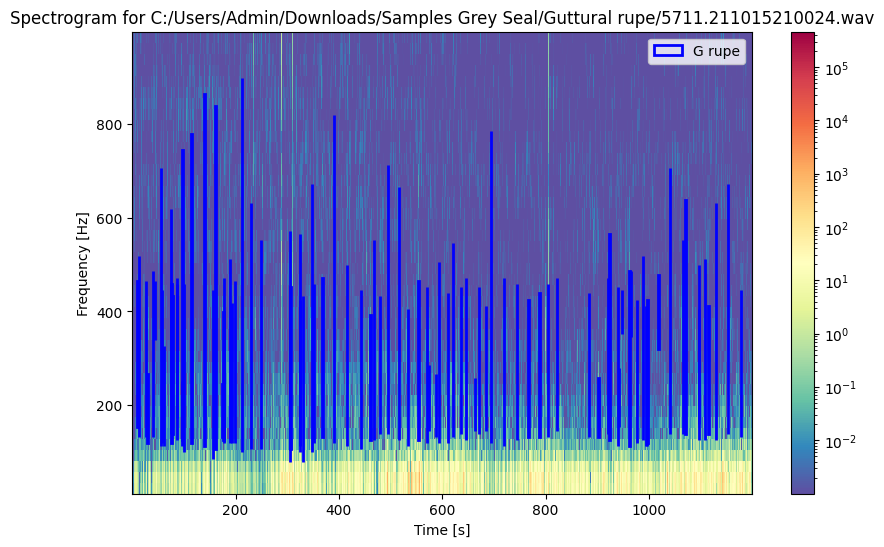

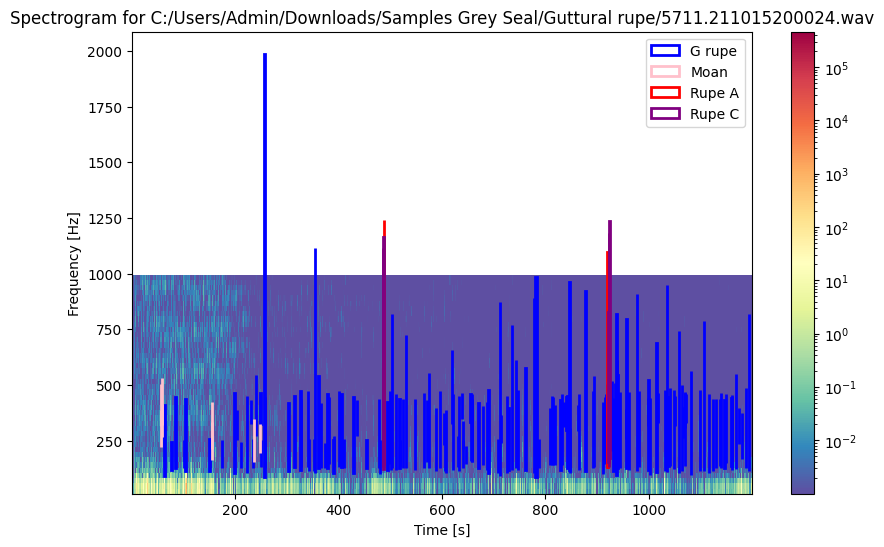

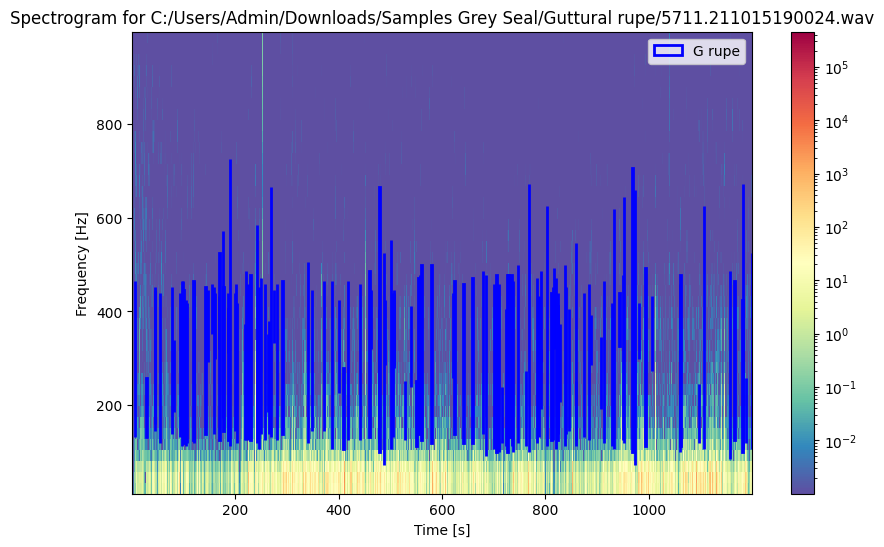

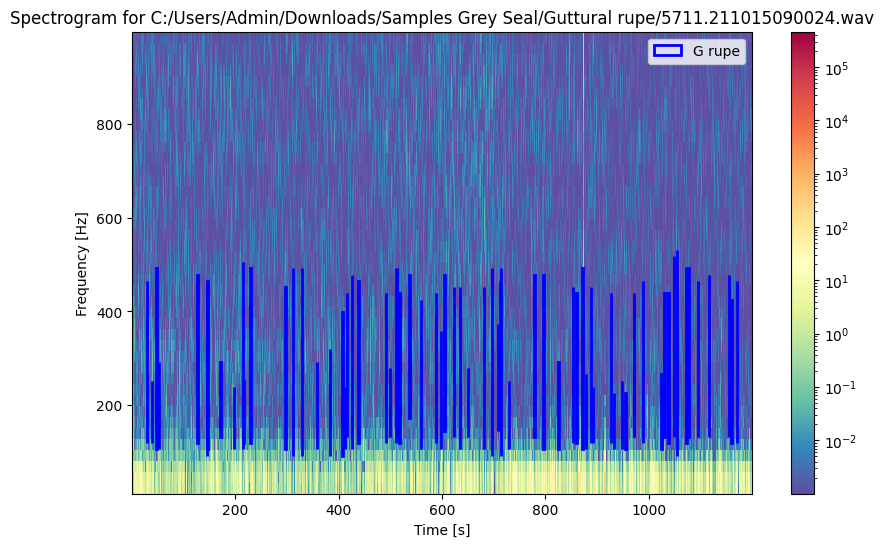

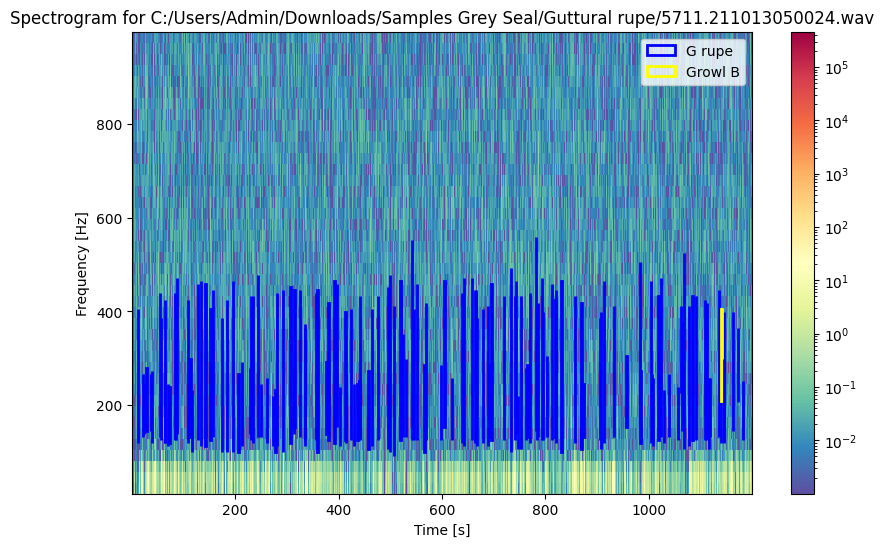

In [11]:
# File paths for the WAV files
file_paths = [
    "C:/Users/Admin/Downloads/Samples Grey Seal/Guttural rupe/5711.211013040024.wav",
    "C:/Users/Admin/Downloads/Samples Grey Seal/Guttural rupe/5711.211015210024.wav",
    "C:/Users/Admin/Downloads/Samples Grey Seal/Guttural rupe/5711.211015200024.wav",
    "C:/Users/Admin/Downloads/Samples Grey Seal/Guttural rupe/5711.211015190024.wav",
    "C:/Users/Admin/Downloads/Samples Grey Seal/Guttural rupe/5711.211015090024.wav",
    "C:/Users/Admin/Downloads/Samples Grey Seal/Guttural rupe/5711.211013050024.wav"
]

# Define colors for annotations
annotation_colors = {
    "Rupe A": "red",
    "Rupe B": "green",
    "Growl B": "yellow",
    "Rupe C": "purple",
    "Moan": "pink",
    "G rupe": "blue"
}

# Function to generate spectrogram
def generate_spectrogram(samples, sample_rate):
    frequencies, times, spectrogram = signal.spectrogram(samples, sample_rate, nperseg=2456, nfft=4096, noverlap=1228, window='hann')
    spectrogram[spectrogram < 0.001] = 0.001  # Trim off tiny values for a proper display

    # Trim in frequency
    fmin, fmax = 20, 1000  # Hz
    freq_slice = np.where((frequencies >= fmin) & (frequencies <= fmax))
    frequencies = frequencies[freq_slice]
    spectrogram = spectrogram[freq_slice, :][0]

    return frequencies, times, spectrogram

# Function to overlay annotations on the spectrogram
def overlay_annotations(ax, df, annotation_colors):
    added_labels = set()  # Ensure each label is added once

    for _, row in df.iterrows():
        start_time = row['Begin Time (s)']
        end_time = row['End Time (s)']
        low_freq = row['Low Freq (Hz)']
        high_freq = row['High Freq (Hz)']
        annotation = row['Annotation']

        if annotation not in annotation_colors:
            continue  # Skip unrecognized annotations

        ax.add_patch(
            plt.Rectangle(
                (start_time, low_freq),
                end_time - start_time,
                high_freq - low_freq,
                edgecolor=annotation_colors[annotation],
                facecolor='none',
                linewidth=2,
                label=annotation if annotation not in added_labels else None
            )
        )
        added_labels.add(annotation)

    ax.legend(loc='upper right')  # Add a legend to the plot

# Iterate over each file
for file in file_paths:
    sample_rate, samples = wavfile.read(file)
    annot_file_path = file.replace('.wav', '.Table.1.selections.txt')
    
    # Read the annotations file into a DataFrame
    df = pd.read_csv(annot_file_path, sep='\t')

    # Generate the spectrogram
    frequencies, times, spectrogram = generate_spectrogram(samples, sample_rate)

    # Create the spectrogram plot
    fig, ax = plt.subplots(figsize=(10, 6))
    pc = ax.pcolormesh(times, frequencies, spectrogram, norm=LogNorm(), cmap='Spectral_r')
    cbar = fig.colorbar(pc)
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [s]')

    # Overlay annotations on the spectrogram
    overlay_annotations(ax, df, annotation_colors)

    # Display the spectrogram
    plt.title(f"Spectrogram for {file}")
    plt.show()


#### Rupe A and B

In [ ]:
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

# File paths for the WAV files
file_paths = [
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210806110002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210908180002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210827200002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210825190002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210823180002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210814160002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210811190002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210811140002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210809120002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210808110002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Rupes A and B\5713.210807110002.wav"
]

# Define colors for annotations
annotation_colors = {
    "Rupe A": "red",
    "Rupe B": "green",
    "Growl B": "yellow",
    "Rupe C": "purple",
    "Moan": "pink",
    "G rupe": "blue"
}

# Function to generate spectrogram
def generate_spectrogram(samples, sample_rate):
    frequencies, times, spectrogram = signal.spectrogram(samples, sample_rate, nperseg=2456, nfft=4096, noverlap=1228, window='hann')
    spectrogram[spectrogram < 0.001] = 0.001  # Trim off tiny values for a proper display

    # Trim in frequency
    fmin, fmax = 20, 1000  # Hz
    freq_slice = np.where((frequencies >= fmin) & (frequencies <= fmax))
    frequencies = frequencies[freq_slice]
    spectrogram = spectrogram[freq_slice, :][0]

    return frequencies, times, spectrogram

# Function to overlay annotations on the spectrogram
def overlay_annotations(ax, df, annotation_colors):
    added_labels = set()  # Ensure each label is added once

    for _, row in df.iterrows():
        start_time = row['Begin Time (s)']
        end_time = row['End Time (s)']
        low_freq = row['Low Freq (Hz)']
        high_freq = row['High Freq (Hz)']
        annotation = row['Annotation']

        if annotation not in annotation_colors:
            continue  # Skip unrecognized annotations

        ax.add_patch(
            plt.Rectangle(
                (start_time, low_freq),
                end_time - start_time,
                high_freq - low_freq,
                edgecolor=annotation_colors[annotation],
                facecolor='none',
                linewidth=2,
                label=annotation if annotation not in added_labels else None
            )
        )
        added_labels.add(annotation)

    ax.legend(loc='upper right')  # Add a legend to the plot

# Iterate over each file
for file in file_paths:
    sample_rate, samples = wavfile.read(file)
    annot_file_path = file.replace('.wav', '.Table.1.selections.txt')
    
    # Read the annotations file into a DataFrame
    df = pd.read_csv(annot_file_path, sep='\t')

    # Generate the spectrogram
    frequencies, times, spectrogram = generate_spectrogram(samples, sample_rate)

    # Create the spectrogram plot
    fig, ax = plt.subplots(figsize=(10, 6))
    pc = ax.pcolormesh(times, frequencies, spectrogram, norm=LogNorm(), cmap='Spectral_r')
    cbar = fig.colorbar(pc)
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [s]')

    # Overlay annotations on the spectrogram
    overlay_annotations(ax, df, annotation_colors)

    # Display the spectrogram
    plt.title(f"Spectrogram for {file}")
    plt.show()


#### Moan

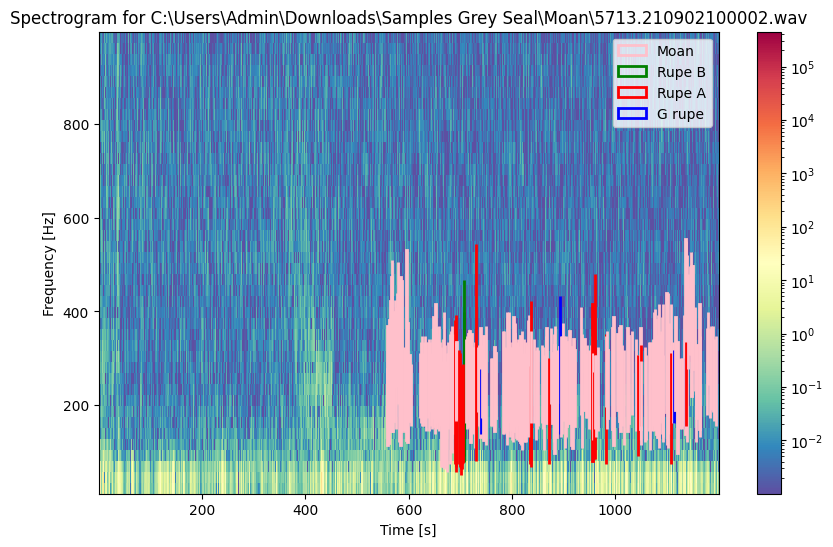

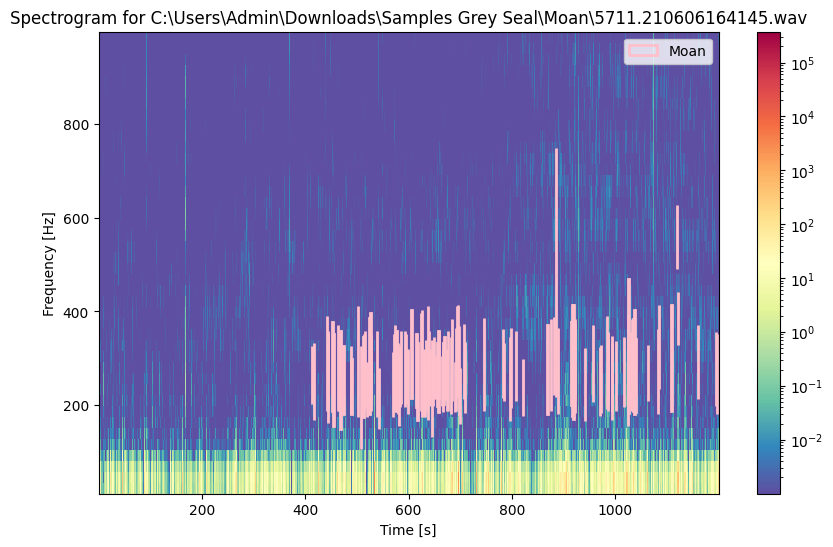

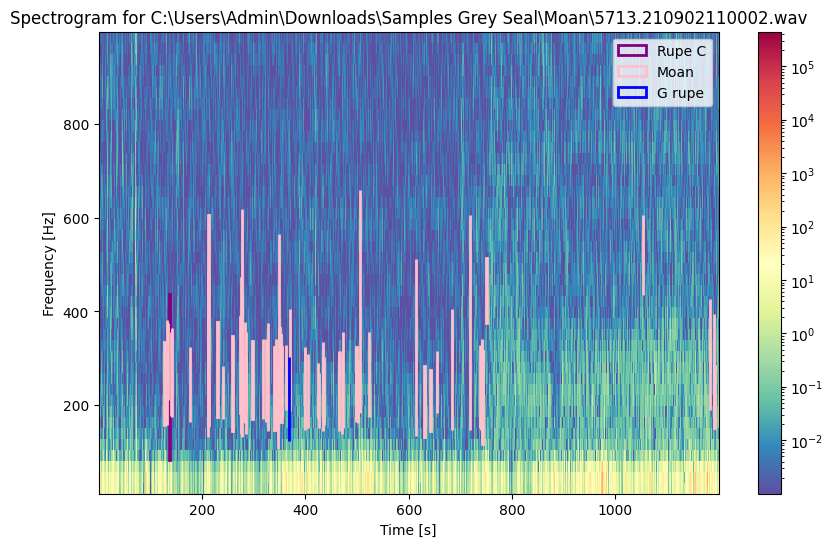

In [15]:
import matplotlib.pyplot as plt
from scipy import signal
from scipy.io import wavfile
import numpy as np
import pandas as pd
from matplotlib.colors import LogNorm

# File paths for the WAV files (Moan category)
file_paths = [
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Moan\5713.210902100002.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Moan\5711.210606164145.wav",
    r"C:\Users\Admin\Downloads\Samples Grey Seal\Moan\5713.210902110002.wav"
]

# Define colors for annotations
annotation_colors = {
    "Rupe A": "red",
    "Rupe B": "green",
    "Growl B": "yellow",
    "Rupe C": "purple",
    "Moan": "pink",
    "G rupe": "blue"
}

# Function to generate spectrogram
def generate_spectrogram(samples, sample_rate):
    frequencies, times, spectrogram = signal.spectrogram(samples, sample_rate, nperseg=2456, nfft=4096, noverlap=1228, window='hann')
    spectrogram[spectrogram < 0.001] = 0.001  # Trim off tiny values for a proper display

    # Trim in frequency
    fmin, fmax = 20, 1000  # Hz
    freq_slice = np.where((frequencies >= fmin) & (frequencies <= fmax))
    frequencies = frequencies[freq_slice]
    spectrogram = spectrogram[freq_slice, :][0]

    return frequencies, times, spectrogram

# Function to overlay annotations on the spectrogram
def overlay_annotations(ax, df, annotation_colors):
    added_labels = set()  # Ensure each label is added once

    for _, row in df.iterrows():
        start_time = row['Begin Time (s)']
        end_time = row['End Time (s)']
        low_freq = row['Low Freq (Hz)']
        high_freq = row['High Freq (Hz)']
        annotation = row['Annotation']

        if annotation not in annotation_colors:
            continue  # Skip unrecognized annotations

        ax.add_patch(
            plt.Rectangle(
                (start_time, low_freq),
                end_time - start_time,
                high_freq - low_freq,
                edgecolor=annotation_colors[annotation],
                facecolor='none',
                linewidth=2,
                label=annotation if annotation not in added_labels else None
            )
        )
        added_labels.add(annotation)

    ax.legend(loc='upper right')  # Add a legend to the plot

# Iterate over each file
for file in file_paths:
    sample_rate, samples = wavfile.read(file)
    annot_file_path = file.replace('.wav', '.Table.1.selections.txt')
    
    # Read the annotations file into a DataFrame
    df = pd.read_csv(annot_file_path, sep='\t')

    # Generate the spectrogram
    frequencies, times, spectrogram = generate_spectrogram(samples, sample_rate)

    # Create the spectrogram plot
    fig, ax = plt.subplots(figsize=(10, 6))
    pc = ax.pcolormesh(times, frequencies, spectrogram, norm=LogNorm(), cmap='Spectral_r')
    cbar = fig.colorbar(pc)
    ax.set_ylabel('Frequency [Hz]')
    ax.set_xlabel('Time [s]')

    # Overlay annotations on the spectrogram
    overlay_annotations(ax, df, annotation_colors)

    # Display the spectrogram
    plt.title(f"Spectrogram for {file}")
    plt.show()


---
# CNN Training Model
#### Dataset Loading Function
Load spectrogram data from the `.npz` files. It excludes "no_call" files and maps annotations to numerical labels.

In [ ]:
# Inspect the contents of one .npz file
data = np.load(os.path.join(dataset_folder, 'moan_629.569042769_630.544762194.npz'))  # Use a sample filename
print(data.files)  # List all available keys in this .npz file


['spectrogram_data', 'frequencies', 'times']


In [ ]:
import os
import numpy as np

# Define the mapping based on your filenames
category_mapping = {
    "moan": 0,
    "rupe_A": 1,
    "rupe_B": 2,
    "rupe_C": 3,
    "growl_B": 4,
    "g_rupe": 5,
}

def load_dataset(dataset_folder):
    spectrograms = []
    labels = []

    # Loop through each npz file in the folder
    for file in os.listdir(dataset_folder):
        if file.endswith(".npz"):
            # Load the .npz file
            data = np.load(os.path.join(dataset_folder, file))
            print(f"File: {file}")
            print("Keys available in this file:", data.files)  # Print the available keys in the .npz file

            # Access the spectrogram directly using the correct key 'spectrogram'
            spectrograms.append(data["spectrogram"])  # Using 'spectrogram' here
            
            # Extract label from the filename
            label = file.split('_')[0]  # Use first part of filename as label
            if label in category_mapping:
                labels.append(category_mapping[label])
            else:
                continue  # Skip files that don't match a known category

    # Convert to NumPy arrays
    spectrograms = np.array(spectrograms)
    labels = np.array(labels)

    return spectrograms, labels

# Load dataset
dataset_folder = r"C:\Users\Admin\Downloads\Machine-Learning\Project_part2\spectrogram_output"
X, y = load_dataset(dataset_folder)

# Check the shape of the data and labels
print(f"Shape of spectrograms: {X.shape}")
print(f"Shape of labels: {y.shape}")


File: 100_g_rupe_spectrogram.npz
Keys available in this file: ['spectrogram', 'metadata']
File: 100_moan_spectrogram.npz
Keys available in this file: ['spectrogram', 'metadata']
File: 100_rupe_A_spectrogram.npz
Keys available in this file: ['spectrogram', 'metadata']
File: 101_g_rupe_spectrogram.npz
Keys available in this file: ['spectrogram', 'metadata']
File: 101_moan_spectrogram.npz
Keys available in this file: ['spectrogram', 'metadata']
File: 101_rupe_A_spectrogram.npz
Keys available in this file: ['spectrogram', 'metadata']
File: 102_g_rupe_spectrogram.npz
Keys available in this file: ['spectrogram', 'metadata']
File: 102_moan_spectrogram.npz
Keys available in this file: ['spectrogram', 'metadata']
File: 102_rupe_A_spectrogram.npz
Keys available in this file: ['spectrogram', 'metadata']
File: 102_rupe_B_spectrogram.npz
Keys available in this file: ['spectrogram', 'metadata']
File: 103_g_rupe_spectrogram.npz
Keys available in this file: ['spectrogram', 'metadata']
File: 103_moan_s

KeyError: 'spectrogram is not a file in the archive'

#### Data Preprocessing
This step normalizes the spectrogram data and prepares it for input into a neural network. 
It also splits the data into training and testing sets.


In [ ]:
# Normalize the spectrogram data
X = X / np.max(X)  # Scale between 0 and 1
X = np.expand_dims(X, -1)  # Add channel dimension for CNNs

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Determine the number of classes
num_classes = len(np.unique(y))


# Building the Neural Network Model
This section creates a simple Convolutional Neural Network (CNN) architecture for multi-class classification.


In [ ]:
# Build a simple CNN model
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(X.shape[1], X.shape[2], 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),  # Regularization
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

# Print model summary
model.summary()


#### Training the Model
Train the model on the training dataset for 30 epochs, with validation split and batch size of 32.
- 30 Epochs are a common starting point to ensure the model has enough time to learn patterns from the data. If the model shows good performance early on (e.g., it stabilizes after just 10–15 epochs), we might shorten the training. 
- The validation split (20% in this case) divides the training data into two parts:
- Batch size of 32 is a typical starting point for deep learning models. It strikes a balance between computational efficiency and stability of training.



In [ ]:
history = model.fit(X_train, y_train, epochs=30, validation_split=0.2, batch_size=32)

#### Evaluating the Model
Evaluate the trained model's performance on the test set and calculate accuracy.

In [ ]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

# Visualizing Loss and Accuracy
Plot the training and validation loss/accuracy curves over the training epochs.


In [ ]:
# Plot training and validation loss
def plot_loss(history, which='loss'):
    plt.plot(history.history[which], label='Training')
    plt.plot(history.history['val_' + which], label='Validation')
    plt.xlabel('Epoch')
    plt.ylabel(which.capitalize())
    plt.legend()
    plt.grid(True)

# Visualize the loss and accuracy
plot_loss(history, 'loss')
plt.title("Loss Over Epochs")
plt.show()

plot_loss(history, 'accuracy')
plt.title("Accuracy Over Epochs")
plt.show()


for tomorrow: # Suggestions for Experiments
- Use **Transfer Learning** with pre-trained CNN models such as ResNet or MobileNet.
- Experiment with **different hyperparameters** (e.g., learning rate, batch size, dropout rate).
- Add **early stopping** or **ReduceLROnPlateau** callbacks.
- Test deeper architectures and explore **regularization techniques** (e.g., L2 regularization).




### Bibliography

1. McKinney, W. (2010). Data Structures for Statistical Computing in Python. *Proceedings of the 9th Python in Science Conference*, 51-56. https://doi.org/10.25080/Majora-92bf1922-00

2. Brown, J.C. (1992). Computational Analysis of Sound Patterns. *Journal of the Acoustical Society of America*, 92(5), 2795-2798. https://doi.org/10.1121/1.407930

3. Oppenheim, A.V., & Schafer, R.W. (1989). *Discrete-Time Signal Processing*. Prentice Hall.

4. Stack Overflow. (2017). *How to convert a WAV file to a spectrogram in Python3*. Retrieved from https://stackoverflow.com/questions/44787437/how-to-convert-a-wav-file-to-a-spectrogram-in-python3

5. Stack Overflow. (2016). *How to create a numpy array from a pydub AudioSegment*. Retrieved from https://stackoverflow.com/questions/38015319/how-to-create-a-numpy-array-from-a-pydub-audiosegment

6. Stack Overflow. (2018). *How do I iterate over files in multiple directories in Python*. Retrieved from https://stackoverflow.com/questions/48133055/how-do-i-iterate-over-files-in-multiple-directories-in-python

7. Stack Overflow. (2017). *Adding together time duration columns in pandas*. Retrieved from https://stackoverflow.com/questions/44752208/adding-together-time-duration-columns-in-pandas

8. Stack Overflow. (2017). *How do I read a CSV file into a pandas dataframe*. Retrieved from https://stackoverflow.com/questions/46449764/how-do-i-read-a-csv-file-into-a-pandas-dataframe

9. Rajeev, R. (2021). *Spectrogram from audio data*. Retrieved from https://www.kaggle.com/code/rajeevratan84/spectrogram-from-audio-data

10. Sophia, G. (2021). *CNN for sound classification - Bird Calls 90%. Retrieved from https://www.kaggle.com/code/sophiagnetneva/cnn-for-sound-classification-bird-calls-90

11. Stack Overflow. (2018). *Extracting no-call segments from audio with gaps between call annotations*. Retrieved from https://stackoverflow.com/questions/50312258/how-do-i-split-a-long-waveform-with-annotated-periods-into-intervals-without-si

12. Stack Overflow. (2016). *How to segment audio based on annotation files?*. Retrieved from https://stackoverflow.com/questions/40011191/how-to-segment-a-wav-file-according-to-annotations-in-pandas

13. Kaggle. (2019). *How to segment data from audio into labeled intervals*. Retrieved from https://www.kaggle.com/competitions/tensorflow-speech-recognition-challenge/discussion/116233

14. Kaggle. (2021). *Handling and extracting segments from audio data*. Retrieved from https://www.kaggle.com/code/borisdayma/audio-steganography/data

15. Doshi, K. (2020). *Audio Deep Learning Made Simple (Part 1): State-of-the-Art Techniques*. Towards Data Science. Retrieved from https://towardsdatascience.com/audio-deep-learning-made-simple-part-1-state-of-the-art-techniques-742e62c29e53

16. Stack Overflow. (2017). *Python - Break up a .wav file by timestamp*. Retrieved from https://stackoverflow.com/questions/44752208/python-break-up-a-wav-file-by-timestamp

17. Kaggle. (2021). *Bird song data set*. Retrieved from https://www.kaggle.com

18. Matplotlib. (2021). *Interactive Matplotlib: ipympl*. Retrieved from https://matplotlib.org/ipympl/